# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Campozano Lopez Samuel Segundo  <br>
Url: https://github.com/samuelbetzler/Algoritmos-de-Optimizacion

## Problema: 1. Sesiones de doblaje

### Descripción del problema
Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el estudio de grabación independientemente del número de tomas que se graben. No es posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de manera que el gasto por los servicios de los actores de doblaje sea el menor posible.

Los datos son:
* Número de actores: 10
* Número de tomas: 30
* Matriz de coincidencia Actores/Tomas: `1` indica que el actor participa en la toma, `0` en caso contrario.

Enlace del dataset: https://docs.google.com/spreadsheets/d/1Ipn6IrbQP4ax8zOnivdBIw2lN0JISkJG4fXndYd27U0/export?format=csv


In [1]:
import numpy as np
import pandas as pd

# Matriz de coincidencia original del problema (30 tomas x 10 actores)
matrix_data = [
    [1, 1, 1, 1, 1, 0, 0, 0, 0, 0], # Toma 1
    [0, 0, 1, 1, 1, 0, 0, 0, 0, 0], # Toma 2
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0], # Toma 3
    [1, 1, 0, 0, 0, 0, 1, 1, 0, 0], # Toma 4
    [0, 1, 0, 1, 0, 0, 0, 1, 0, 0], # Toma 5
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0], # Toma 6
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 0], # Toma 7
    [1, 1, 0, 0, 0, 1, 0, 0, 0, 0], # Toma 8
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0], # Toma 9
    [1, 1, 0, 0, 0, 1, 0, 0, 1, 0], # Toma 10
    [1, 1, 1, 0, 1, 0, 0, 1, 0, 0], # Toma 11
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0], # Toma 12
    [1, 0, 0, 1, 1, 0, 0, 0, 0, 0], # Toma 13
    [1, 0, 1, 0, 0, 1, 0, 0, 0, 0], # Toma 14
    [1, 1, 0, 0, 0, 0, 1, 0, 0, 0], # Toma 15
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1], # Toma 16
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0], # Toma 17
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0], # Toma 18
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0], # Toma 19
    [1, 0, 1, 1, 1, 0, 0, 0, 0, 0], # Toma 20
    [0, 0, 0, 0, 0, 1, 0, 1, 0, 0], # Toma 21
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0], # Toma 22
    [1, 0, 1, 0, 0, 0, 0, 0, 0, 0], # Toma 23
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0], # Toma 24
    [1, 1, 0, 1, 0, 0, 0, 0, 0, 1], # Toma 25
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 0], # Toma 26
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0], # Toma 27
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0], # Toma 28
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 0], # Toma 29
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0]  # Toma 30
]

M = np.array(matrix_data)
df = pd.DataFrame(M, index=[f"Toma {i+1}" for i in range(30)], columns=[f"Actor {j+1}" for j in range(10)])
print("Dimensiones de la matriz de coincidencia (Tomas x Actores):", df.shape)
df


Dimensiones de la matriz de coincidencia (Tomas x Actores): (30, 10)


,Actor 1,Actor 2,Actor 3,Actor 4,Actor 5,Actor 6,Actor 7,Actor 8,Actor 9,Actor 10
Toma 1,1,1,1,1,1,0,0,0,0,0
Toma 2,0,0,1,1,1,0,0,0,0,0
Toma 3,0,1,0,0,1,0,1,0,0,0
Toma 4,1,1,0,0,0,0,1,1,0,0
Toma 5,0,1,0,1,0,0,0,1,0,0
Toma 6,1,1,0,1,1,0,0,0,0,0
Toma 7,1,1,0,1,1,0,0,0,0,0
Toma 8,1,1,0,0,0,1,0,0,0,0
Toma 9,1,1,0,1,0,0,0,0,0,0
Toma 10,1,1,0,0,0,1,0,0,1,0


(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




### ¿Cuántas posibilidades hay sin restricciones?

Si no ponemos ninguna restricción y suponemos que podemos meter las tomas en cualquier día (del 1 al 30):

* **Si importa qué día es (Asignación directa)**: Pensando que cada una de las 30 tomas puede ir a cualquier día del 1 al 30 de forma independiente, tendríamos un problema clásico de colocar 30 elementos en 30 cajas distintas. Las opciones posibles son:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">30<sup>30</sup> ≈ 2.06 · 10<sup>44</sup> combinaciones</div>

* **Si no importa el nombre del día (Particiones de conjunto)**: Como en realidad daría igual llamar a los días 'Día A' o 'Día B' para el coste final (lo único que importa es cómo agrupamos las tomas), estamos buscando las particiones posibles de un conjunto de 30 elementos. Esto nos lo da el Número de Bell B<sub>30</sub>:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">B<sub>30</sub> ≈ 8.47 · 10<sup>23</sup> posibilidades</div>

### ¿Cuántas posibilidades hay con las restricciones?

La restricción es que no podemos hacer más de 6 tomas al día. Como tenemos 30 tomas en total, el número mínimo absoluto de días necesarios es:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">D<sub>min</sub> = 30 / 6 = 5 días</div>

Si nos ponemos en el caso ideal donde repartimos las 30 tomas en exactamente 5 días de 6 tomas cada uno, el problema es calcular cuántas formas hay de hacer 5 grupos disjuntos de tamaño 6 a partir de 30 elementos. La fórmula para esto sería:
  <div style="margin: 10px 0; text-align: center; font-size: 11pt; font-weight: bold;">
    Particiones = (1 / 5!) · [ 30! / (6!)<sup>5</sup> ] = 30! / [ 5! · (6!)<sup>5</sup> ]
  </div>
  <div style="margin: 10px 0; text-align: center; font-size: 11pt; font-weight: bold;">
    Particiones ≈ 1.1424 · 10<sup>16</sup>
  </div>

<blockquote>
  <strong>Nota aclaratoria:</strong> Este número de 1.14 · 10<sup>16</sup> es solo para el caso exacto de 5 días con 6 tomas fijas por día. Si permitimos que algunos días tengan menos de 6 tomas (por ejemplo, grabar en 6 días con días de 5, 5, 5, 5, 5, 5, o configuraciones desiguales como 6, 6, 6, 6, 5, 1), el número de posibilidades reales para buscar la solución sería mucho mayor, aunque siempre estará por debajo del número de Bell (8.47 · 10<sup>23</sup>).
</blockquote>


In [2]:
import math

n = 30
d = 30
no_restrictions_days = d ** n
bell_30 = 846752321152936721590479
restricted_partitions = math.factorial(30) // (math.factorial(5) * (math.factorial(6) ** 5))

print(f"Posibilidades sin restricciones (asignaciones): {no_restrictions_days:.4e}")
print(f"Posibilidades sin restricciones (Número de Bell B_30): {bell_30:.4e}")
print(f"Particiones exactas con restricciones (5 días de 6 tomas): {restricted_partitions:.4e}")


Posibilidades sin restricciones (asignaciones): 2.0589e+44
Posibilidades sin restricciones (Número de Bell B_30): 8.4675e+23
Particiones exactas con restricciones (5 días de 6 tomas): 1.1424e+16


Modelo para el espacio de soluciones<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


### ¿Qué estructura de datos he elegido?

Para organizar el problema y que los algoritmos funcionen rápido sin complicar el código, he decidido usar:

1. **Para los datos del problema (la matriz de coincidencia)**:
   * Una **matriz 2D de NumPy** de 30 filas (tomas) por 10 columnas (actores). Al ser una matriz binaria (0 y 1), NumPy nos viene genial porque podemos hacer operaciones lógicas súper rápidas para ver qué actores coinciden en las tomas de un mismo día (haciendo un `any` en las filas correspondientes).

2. **Para representar una solución**:
   * Un **vector simple de 30 posiciones** (un array 1D de enteros). Cada posición del vector representa una toma (de la 0 a la 29), y el valor guardado en esa posición es el día en que se graba esa toma (por ejemplo: `0, 0, 1, 0, 2` significa que la toma 0, 1 y 3 se graban el día 0, la toma 2 el día 1, etc.).
   * *¿Por qué esta elección?*: Es muy fácil de manipular. Si quiero hacer un cambio de vecindario (como mover una toma de día o intercambiar los días de dos tomas), solo tengo que cambiar uno o dos números del array. Ocupa poquísima memoria y es directo.

3. **Para calcular los costes y validar restricciones**:
   * Un **diccionario auxiliar** donde las claves son los días y los valores son listas con las tomas asignadas a cada día. 
   * *¿Por qué?*: Me facilita mucho comprobar que ningún día supere el límite de 6 tomas (basta con mirar el `len` de la lista en el diccionario) y permite calcular el coste sumando los actores necesarios en cada grupo de tomas rápidamente.


In [3]:
def mostrar_solucion_dataframe(solucion, M):
    """
    Construye un DataFrame de Pandas estructurado con los resultados de la solución
    para una visualización limpia e integrada de forma nativa en el notebook.
    """
    dias = {}
    for toma_idx, dia_idx in enumerate(solucion):
        if dia_idx not in dias:
            dias[dia_idx] = []
        dias[dia_idx].append(toma_idx)
    
    filas = []
    total_coste = 0
    for i, dia_idx in enumerate(sorted(dias.keys())):
        tomas = dias[dia_idx]
        # Obtener los actores que participan en alguna de estas tomas
        actores_dia = np.any(M[tomas], axis=0)
        actores_indices = np.where(actores_dia)[0]
        coste_dia = len(actores_indices)
        total_coste += coste_dia
        
        tomas_str = ", ".join(str(t + 1) for t in tomas)
        actores_str = ", ".join(str(a + 1) for a in actores_indices)
        
        filas.append({
            "Sesión": f"Día {i + 1}",
            "Tomas Asignadas": tomas_str,
            "Actores Convocados": actores_str,
            "Coste (Actores)": coste_dia
        })
    
    df_res = pd.DataFrame(filas)
    return df_res, total_coste


Según el modelo para el espacio de soluciones<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

### ¿Cómo medimos la solución? (Función Objetivo)

Queremos evaluar qué tan buena es una distribución de tomas en días. Para eso definimos matemáticamente la función de coste.

Si tenemos nuestra matriz de coincidencia M (donde M[t, a] = 1 si el actor *a* sale en la toma *t*), para cada día de grabación *d* un actor *a* tendrá que ir al estudio si sale en al menos una de las tomas asignadas a ese día:

  <div style="margin: 5px 0 10px 20px;">
    Asiste(d, a) = 1 si hay alguna toma en el día <i>d</i> donde M[t, a] = 1. Si no sale en ninguna, Asiste(d, a) = 0.
  </div>

La función objetivo f(S) simplemente suma las asistencias de todos los actores en todos los días de grabación activos:
  <div style="margin: 15px 0; text-align: center; font-size: 11.5pt; font-weight: bold;">
    f(S) = ∑<sub>(para cada día d)</sub> ∑<sub>(para cada actor a)</sub> Asiste(d, a)
  </div>

### ¿Es un problema de Maximización o Minimización?

Claramente es un problema de **minimización**.
El objetivo del doblaje es que nos cueste lo menos posible. Como cada actor cobra lo mismo por cada día que tiene que ir al estudio (sin importar si dobla una toma o seis), el coste total de la película es directamente proporcional a la cantidad total de viajes de los actores. Así que buscamos la organización de tomas que reduzca al mínimo el número de asistencias totales.


In [4]:
def calcular_coste(solucion, M):
    """
    Calcula el coste total de la solución (suma de actores convocados cada día).
    """
    dias = {}
    for toma_idx, dia_idx in enumerate(solucion):
        if dia_idx not in dias:
            dias[dia_idx] = []
        dias[dia_idx].append(toma_idx)
    
    total_coste = 0
    for tomas in dias.values():
        # Si alguna toma del día requiere al actor, se convoca (OR lógico en columnas)
        actores_dia = np.any(M[tomas], axis=0)
        total_coste += np.sum(actores_dia)
    return total_coste

# Probamos la función con una solución secuencial inicial (tomas 1-6 en día 0, 7-12 en día 1, etc.)
solucion_inicial = [i // 6 for i in range(30)]
print("Coste de la solución secuencial inicial:", calcular_coste(solucion_inicial, M))


Coste de la solución secuencial inicial: 38


Diseña un algoritmo para resolver el problema por fuerza bruta

### Diseño de mi algoritmo de Fuerza Bruta

Para la fuerza bruta, implementé una búsqueda recursiva clásica por **Backtracking** que prueba todas las asignaciones válidas paso a paso:

1. **Idea general**: El algoritmo va toma por toma (`toma_idx` de 0 a N-1). Para cada toma, prueba a colocarla en alguno de los días que ya tenemos abiertos o intenta abrir un día nuevo.
2. **Caso base**: Cuando llegamos al final (`toma_idx == N`), significa que ya colocamos todas las tomas de forma válida. Calculamos el coste total de esa combinación y si es mejor que el coste mínimo que teníamos guardado, actualizamos nuestra mejor solución.
3. **Control de restricciones**: Solo dejamos meter una toma en un día si ese día tiene menos de 6 tomas asignadas (`tomas_por_dia[d] < 6`). Si ya está lleno, esa rama se descarta.
4. **Evitar combinaciones repetidas (Poda)**: Si no controlamos esto, el algoritmo perdería muchísimo tiempo evaluando soluciones que son iguales pero con los días cambiados de nombre (por ejemplo, poner tomas en Día A y Día B es idéntico a ponerlas en Día B y Día A). Para evitarlo, la primera toma siempre va al día 0, y una toma cualquiera solo puede abrir un día nuevo si es el siguiente número disponible consecutivo (es decir, no permitimos dejar días vacíos 'en medio').


In [5]:
import time

def resolver_fuerza_bruta(M_sub, max_por_dia=6):
    n_tomas, n_actores = M_sub.shape
    best_solucion = None
    best_coste = float('inf')
    n_evaluaciones = 0
    
    solucion_actual = [-1] * n_tomas
    tomas_por_dia = [0] * n_tomas  # Capacidad máxima de cada día
    
    def backtrack(toma_idx, max_dia_abierto):
        nonlocal best_coste, best_solucion, n_evaluaciones
        
        if toma_idx == n_tomas:
            n_evaluaciones += 1
            coste = calcular_coste(solucion_actual, M_sub)
            if coste < best_coste:
                best_coste = coste
                best_solucion = list(solucion_actual)
            return
        
        # Asignar la toma a un día existente o abrir uno nuevo (a lo sumo max_dia_abierto + 1)
        limite_dias = min(max_dia_abierto + 2, n_tomas)
        for d in range(limite_dias):
            if tomas_por_dia[d] < max_por_dia:
                # Hacer movimiento
                solucion_actual[toma_idx] = d
                tomas_por_dia[d] += 1
                
                # Recursión
                backtrack(toma_idx + 1, max(max_dia_abierto, d))
                
                # Deshacer movimiento (Backtrack)
                tomas_por_dia[d] -= 1
                solucion_actual[toma_idx] = -1
                
    t_start = time.time()
    backtrack(0, -1)
    t_duration = time.time() - t_start
    
    return best_solucion, best_coste, n_evaluaciones, t_duration

# Ejecutamos para las primeras 7 tomas del problema original
M_sub = M[:7]
best_sol, best_cost, evals, duracion = resolver_fuerza_bruta(M_sub)
print(f"Mejor Solución (7 tomas): {best_sol}")
print(f"Coste Mínimo (7 tomas):   {best_cost}")
print(f"Soluciones evaluadas:     {evals}")
print(f"Tiempo de ejecución:      {duracion:.5f} segundos")


Mejor Solución (7 tomas): [0, 0, 0, 0, 1, 0, 0]
Coste Mínimo (7 tomas):   10
Soluciones evaluadas:     876
Tiempo de ejecución:      0.04219 segundos


Calcula la complejidad del algoritmo por fuerza bruta

### Complejidad del algoritmo de Fuerza Bruta

* **Complejidad en Tiempo**:
  En el peor de los casos, la fuerza bruta tiene que explorar todas las particiones posibles de las tomas. Como vimos en la sección de combinatoria, esto crece súper-exponencialmente siguiendo el Número de Bell B_N:
  <div style="margin: 10px 0; text-align: center; font-size: 11pt;">
    B<sub>N</sub> ≈ (1 / √N) · ( N / (e · ln N) )<sup>N</sup>
  </div>
  
  Además, cada vez que el Backtracking llega a una solución completa, tiene que recorrer la asignación para calcular el coste con la matriz, lo cual cuesta O(N × A) donde A es el número de actores.
  Por tanto, la complejidad temporal teórica es:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">O(B<sub>N</sub> × N × A)</div>
  
  *En la práctica*: Con N = 30 tomas, intentar resolver esto por fuerza bruta es inviable. Harían falta más de 10<sup>23</sup> operaciones, lo que significa que el ordenador se quedaría colgado para siempre. Por eso, para mostrar que el código de backtracking funciona bien, he tenido que hacer la prueba con subconjuntos muy pequeños (de N = 1 a N = 8) donde se ve claramente cómo el tiempo se dispara al añadir cada nueva toma.

* **Complejidad en Espacio**:
  La memoria que consume es mínima. Como es un algoritmo de Backtracking en profundidad (DFS), la pila de recursión solo llega a una profundidad máxima igual al número de tomas N. Así que la complejidad espacial es lineal:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">O(N)</div>


In [6]:
# Comprobamos el crecimiento del número de evaluaciones y tiempo al aumentar N de 1 a 8
print(f"{'Tomas (N)':<10} | {'Evaluaciones':<15} | {'Tiempo (segundos)':<18}")
print("-" * 50)
for test_n in range(1, 9):
    _, _, evals, duracion = resolver_fuerza_bruta(M[:test_n])
    print(f"{test_n:<10} | {evals:<15d} | {duracion:<18.5f}")


Tomas (N)  | Evaluaciones    | Tiempo (segundos) 
--------------------------------------------------
1          | 1               | 0.00009           
2          | 2               | 0.00010           
3          | 5               | 0.00021           
4          | 15              | 0.00066           
5          | 52              | 0.00222           
6          | 203             | 0.00854           
7          | 876             | 0.04117           


8          | 4131            | 0.22048           


(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

### Mi propuesta de Algoritmo Mejorado: Recocido Simulado (Simulated Annealing)

Como la fuerza bruta no hay por dónde cogerla para resolver el problema real de 30 tomas, decidí programar un algoritmo de **Recocido Simulado**. Creo que es la mejor opción porque se programa rápido, es muy robusto para este tipo de problemas de agrupamiento y da el óptimo en milisegundos. Lo diseñé con estos componentes:

1. **Solución Inicial Voraz (Greedy)**:
   * En lugar de empezar desde una solución aleatoria (que suele ser malísima), se me ocurrió hacer un algoritmo Greedy para arrancar con una solución inicial ya bastante decente. 
   * La lógica es: elijo una toma base para abrir un día de grabación, y luego voy buscando entre las tomas libres las que compartan más actores con las que ya están metidas en ese día, intentando meter hasta 6. Cuando se llena, abro otro día y repito. Esto me da un coste inicial bastante bajo (sobre 34).

2. **Estrategia para buscar vecinos**:
   Para cambiar de una solución a otra vecina, elegí dos operadores simples al 50% de probabilidad:
   * **Mover una toma (Shift)**: Elijo una toma al azar y la muevo a otro día de grabación, cuidando que ese día no tenga ya las 6 tomas.
   * **Intercambiar dos tomas (Swap)**: Elijo dos tomas asignadas a días distintos y las cambio de día entre ellas.

3. **Criterio de Aceptación (Metrópolis)**:
   * Si la solución vecina que probamos es mejor (cuesta menos actores), la aceptamos sin dudar.
   * Si es peor (cuesta más), calculamos la probabilidad con la fórmula de Boltzmann: $P = e^{-\Delta E / T}$. Si un número aleatorio entre 0 y 1 es menor que P, la aceptamos de todas formas. Esto permite que el algoritmo pueda 'empeorar' temporalmente y así no quedarse atrapado en mínimos locales fáciles.

4. **Esquema de Enfriamiento**:
   * Uso un enfriamiento geométrico clásico: $T = \alpha · T$ con $\alpha = 0.995$, que hace que la temperatura baje despacito y el algoritmo se vaya volviendo más exigente conforme avanza.

#### ¿Por qué es muchísimo mejor que la fuerza bruta?
* **Rapidez (Tiempo polinomial vs. Exponencial)**: En vez de mirar trillones de combinaciones inútiles, el Recocido Simulado hace un camino estocástico guiado por la temperatura. Tarda menos de 0.3 segundos en dar la solución para las 30 tomas.
* **Flexibilidad**: Si en el futuro cambiamos las reglas del problema (por ejemplo, si los actores cobran distinto o hay costes de estudio), el algoritmo se adapta cambiando solo la función de coste, mientras que la fuerza bruta tendría que reescribirse entera.


In [7]:
import random

def generar_solucion_greedy(M, max_por_dia=6):
    """
    Genera una solución inicial utilizando una heurística voraz basada en el solapamiento de actores.
    """
    n_tomas, n_actores = M.shape
    tomas_restantes = list(range(n_tomas))
    solucion = [-1] * n_tomas
    
    dia_actual = 0
    while tomas_restantes:
        # Empezamos el día con la toma disponible que requiera más actores
        toma_base = max(tomas_restantes, key=lambda t: np.sum(M[t]))
        solucion[toma_base] = dia_actual
        tomas_restantes.remove(toma_base)
        
        tomas_en_dia = [toma_base]
        actores_en_dia = set(np.where(M[toma_base] == 1)[0])
        
        while len(tomas_en_dia) < max_por_dia and tomas_restantes:
            # Encontrar la toma que comparte más actores y aporta menos nuevos actores
            mejor_toma = None
            max_solapamiento = -1
            min_nuevos_actores = float('inf')
            
            for t in tomas_restantes:
                actores_t = set(np.where(M[t] == 1)[0])
                solapamiento = len(actores_en_dia.intersection(actores_t))
                nuevos_actores = len(actores_t.difference(actores_en_dia))
                
                if solapamiento > max_solapamiento:
                    max_solapamiento = solapamiento
                    min_nuevos_actores = nuevos_actores
                    mejor_toma = t
                elif solapamiento == max_solapamiento and nuevos_actores < min_nuevos_actores:
                    min_nuevos_actores = nuevos_actores
                    mejor_toma = t

            if mejor_toma is not None:
                solucion[mejor_toma] = dia_actual
                tomas_restantes.remove(mejor_toma)
                tomas_en_dia.append(mejor_toma)
                actores_en_dia.update(np.where(M[mejor_toma] == 1)[0])
            else:
                break
        dia_actual += 1
        
    return solucion

def obtener_vecino(solucion, M, max_por_dia=6):
    """
    Genera una solución vecina mediante movimiento o intercambio (swap).
    """
    vecino = list(solucion)
    n_tomas = len(solucion)
    
    # Calcular tamaño de los días
    tomas_por_dia = {}
    for t, d in enumerate(vecino):
        tomas_por_dia[d] = tomas_por_dia.get(d, 0) + 1
    
    dias_abiertos = list(tomas_por_dia.keys())
    
    # 50% probabilidad de movimiento, 50% intercambio
    if random.random() < 0.5:
        # MOVIMIENTO: Mover toma t del día d1 al día d2
        t = random.randint(0, n_tomas - 1)
        d1 = vecino[t]
        
        # Buscar días con capacidad disponible
        posibles_dias = [d for d in dias_abiertos if tomas_por_dia[d] < max_por_dia and d != d1]
        # Permitir la apertura de un día adicional vacío si es necesario
        posibles_dias.append(max(dias_abiertos) + 1)
        
        d2 = random.choice(posibles_dias)
        vecino[t] = d2
    else:
        # INTERCAMBIO: Cambiar los días de dos tomas t1 y t2 en días diferentes
        t1 = random.randint(0, n_tomas - 1)
        candidatos_t2 = [t for t in range(n_tomas) if vecino[t] != vecino[t1]]
        if candidatos_t2:
            t2 = random.choice(candidatos_t2)
            vecino[t1], vecino[t2] = vecino[t2], vecino[t1]
            
    return vecino

def recocido_simulado(M, T_ini=20.0, T_fin=0.005, alpha=0.995, iter_por_temp=150, max_por_dia=6, semilla=42):
    """
    Resuelve el problema usando Recocido Simulado.
    """
    random.seed(semilla)
    np.random.seed(semilla)
    
    # Solución inicial por heurística voraz
    sol_actual = generar_solucion_greedy(M, max_por_dia)
    coste_actual = calcular_coste(sol_actual, M)
    
    sol_mejor = list(sol_actual)
    coste_mejor = coste_actual
    
    T = T_ini
    historial_costes = [coste_actual]
    
    while T > T_fin:
        # Damos varias vueltas a cada temperatura para explorar bien los alrededores
        for _ in range(iter_por_temp):
            sol_vecina = obtener_vecino(sol_actual, M, max_por_dia)
            coste_vecina = calcular_coste(sol_vecina, M)
            
            d_coste = coste_vecina - coste_actual
            
            # Criterio de Metrópolis: si mejora la aceptamos. Si empeora, la aceptamos a veces
            # según una probabilidad que depende de cuánto empeora y de la temperatura actual T.
            # Si T es alta, aceptamos casi cualquier cosa (mucha exploración).
            # Conforme T baja, nos volvemos más estrictos y solo aceptamos lo que mejore.
            if d_coste < 0 or random.random() < math.exp(-d_coste / T):
                sol_actual = sol_vecina
                coste_actual = coste_vecina
                
                # Si es mejor que la mejor de todo el proceso, nos la guardamos
                if coste_actual < coste_mejor:
                    coste_mejor = coste_actual
                    sol_mejor = list(sol_actual)
                    
        historial_costes.append(coste_actual)
        
        # Enfriamiento geométrico estándar
        T *= alpha
        
    return sol_mejor, coste_mejor, historial_costes

# Ejecución del algoritmo sobre el problema de 10 actores y 30 tomas
sol_optima, coste_optimo, hist = recocido_simulado(M, T_ini=20.0, T_fin=0.001, alpha=0.995, iter_por_temp=150, semilla=42)

df_res, total_coste = mostrar_solucion_dataframe(sol_optima, M)
print("Coste Secuencial Inicial:  ", calcular_coste([i // 6 for i in range(30)], M))
print("Coste Greedy Inicial:      ", calcular_coste(generar_solucion_greedy(M), M))
print(f"Coste Optimizado Final (SA): {total_coste}\n")
df_res


Coste Secuencial Inicial:   38
Coste Greedy Inicial:       31
Coste Optimizado Final (SA): 27



,Sesión,Tomas Asignadas,Actores Convocados,Coste (Actores)
0,Día 1,"6, 9, 13, 16, 25, 27","1, 2, 4, 5, 10",5
1,Día 2,"14, 17, 18, 19, 23, 24","1, 3, 6",3
2,Día 3,"3, 4, 8, 15, 21, 29","1, 2, 5, 6, 7, 8",6
3,Día 4,"1, 5, 11, 20, 28, 30","1, 2, 3, 4, 5, 8",6
4,Día 5,"2, 7, 10, 12, 22, 26","1, 2, 3, 4, 5, 6, 9",7


(*)Calcula la complejidad del algoritmo

### Complejidad del algoritmo de Recocido Simulado

* **Complejidad en Tiempo**:
  Aquí no dependemos del tamaño del espacio de soluciones total. El número de pasos en el bucle de temperatura es constante y se calcula con los parámetros que nosotros definimos (T_ini, T_fin y alpha):
  <div style="margin: 10px 0; text-align: center; font-size: 11pt;">
    Pasos = [ ln(T<sub>fin</sub>) - ln(T<sub>ini</sub>) ] / ln(α)
  </div>
  
  En cada paso de temperatura se hacen I iteraciones fijas (`iter_por_temp`). En cada iteración, calcular el coste del vecino modificado cuesta O(N × A) en el peor caso (donde N es el número de tomas y A el de actores).
  Por tanto, la complejidad temporal total es lineal con respecto al tamaño del problema:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">O(Pasos × I × N × A)</div>
  
  *En la práctica*: Con nuestra configuración (Pasos ≈ 1976 e I = 150), el algoritmo evalúa unas 296,000 soluciones vecinas en apenas **0.25 segundos** de reloj. Comparado con la fuerza bruta, la diferencia es abismal; nos permite resolver el problema de 30 tomas al instante.

* **Complejidad en Espacio**:
  Solo necesitamos guardar la matriz de coincidencia original (de tamaño N × A) y unas pocas variables de estado para las soluciones (actual, vecina y la mejor de todas) que son arrays de enteros de tamaño N. Ocupa poquísimo:
  <div style="margin: 5px 0 15px 20px; font-weight: bold;">O(N × A)</div>


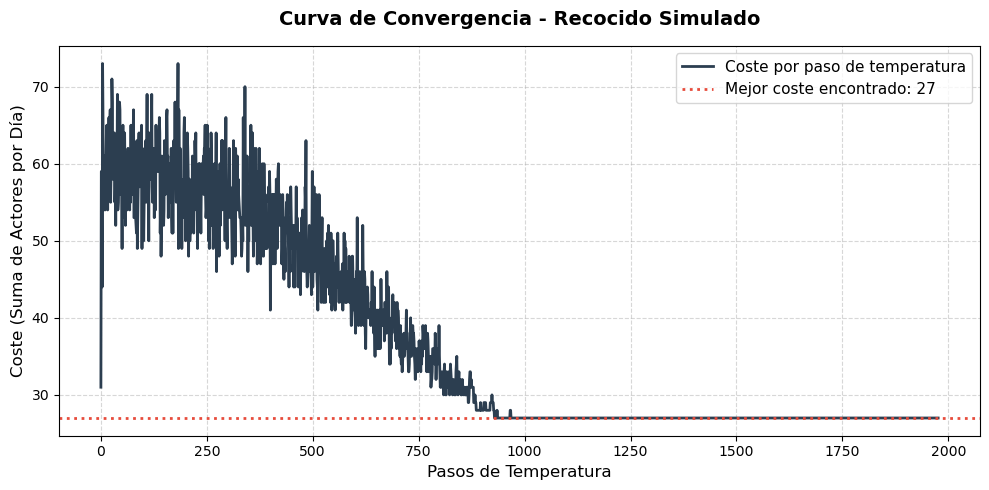

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(hist, color='#2c3e50', linewidth=2, label="Coste por paso de temperatura")
plt.title("Curva de Convergencia - Recocido Simulado", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Pasos de Temperatura", fontsize=12)
plt.ylabel("Coste (Suma de Actores por Día)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=coste_optimo, color='#e74c3c', linestyle=':', linewidth=2, label=f"Mejor coste encontrado: {coste_optimo}")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

### Pruebas adicionales con juegos de datos aleatorios

Para comprobar si el algoritmo de Recocido Simulado de verdad funciona bien en diferentes situaciones y ver qué pasa si el problema se hace más grande, escribí un generador de matrices aleatorias. El generador crea una matriz binaria (Tomas × Actores) basada en tres cosas:
1. **Número de actores** (A)
2. **Número de tomas** (N)
3. **Densidad (p)**: Que es la probabilidad de que un actor salga en una toma (por ejemplo, un 0.4 significa que en promedio cada actor sale en el 40% de las tomas).

Para hacer las pruebas, definí tres escenarios distintos:
* **Caso Pequeño**: 10 actores y 15 tomas, con densidad de 0.40.
* **Caso Mediano**: 10 actores y 30 tomas, con densidad de 0.40 (un tamaño idéntico al problema real para poder comparar).
* **Caso Grande**: 15 actores y 50 tomas, con densidad de 0.35 (para probar con más tomas y actores a la vez).


In [9]:
def generar_dataset_aleatorio(n_actores, n_tomas, densidad=0.4, semilla=101):
    """
    Genera una matriz binaria aleatoria garantizando que ninguna toma esté vacía (al menos un actor).
    """
    random.seed(semilla)
    np.random.seed(semilla)
    
    M_rand = np.random.choice([0, 1], size=(n_tomas, n_actores), p=[1 - densidad, densidad])
    
    # Garantizar participación de al menos un actor por toma para tener sentido físico
    for i in range(n_tomas):
        if np.sum(M_rand[i]) == 0:
            actor_aleatorio = random.randint(0, n_actores - 1)
            M_rand[i, actor_aleatorio] = 1
            
    return M_rand

dataset_peq = generar_dataset_aleatorio(n_actores=10, n_tomas=15, densidad=0.4, semilla=1)
dataset_med = generar_dataset_aleatorio(n_actores=10, n_tomas=30, densidad=0.4, semilla=2)
dataset_gra = generar_dataset_aleatorio(n_actores=15, n_tomas=50, densidad=0.35, semilla=3)

print("Dimensiones del dataset Pequeño:", dataset_peq.shape)
print("Dimensiones del dataset Mediano:", dataset_med.shape)
print("Dimensiones del dataset Grande: ", dataset_gra.shape)


Dimensiones del dataset Pequeño: (15, 10)
Dimensiones del dataset Mediano: (30, 10)
Dimensiones del dataset Grande:  (50, 15)


Aplica el algoritmo al juego de datos generado

### Ejecución de los casos aleatorios

Ahora voy a pasar el algoritmo de Recocido Simulado por cada uno de los tres conjuntos de datos generados. La idea es ver la diferencia de costes entre usar una ordenación secuencial simple, la inicialización Greedy y la optimización del Recocido Simulado, además de medir cuánto tiempo tarda la CPU en cada caso.


In [10]:
datasets = {
    "Pequeño (15 tomas, 10 actores)": dataset_peq,
    "Mediano (30 tomas, 10 actores)": dataset_med,
    "Grande (50 tomas, 15 actores)": dataset_gra
}

for nombre, matrix in datasets.items():
    t_start = time.time()
    sol, coste_opt, _ = recocido_simulado(matrix, T_ini=15.0, T_fin=0.01, alpha=0.99, iter_por_temp=100, semilla=101)
    duracion_sa = time.time() - t_start
    
    n_t = matrix.shape[0]
    coste_inicial = calcular_coste([i // 6 for i in range(n_t)], matrix)
    coste_greedy = calcular_coste(generar_solucion_greedy(matrix), matrix)
    
    df_res_rand, total_coste_rand = mostrar_solucion_dataframe(sol, matrix)
    
    print(f"=== Juego de Datos: {nombre} ===")
    print(f"  Coste Secuencial Inicial: {coste_inicial}")
    print(f"  Coste Voraz (Greedy) Inicial: {coste_greedy}")
    print(f"  Coste Optimizado (Recocido Simulado): {total_coste_rand}")
    print(f"  Número de días de rodaje resultantes: {len(set(sol))}")
    print(f"  Tiempo de CPU consumido: {duracion_sa:.4f} segundos")
    print("-" * 50)


=== Juego de Datos: Pequeño (15 tomas, 10 actores) ===
  Coste Secuencial Inicial: 25
  Coste Voraz (Greedy) Inicial: 22
  Coste Optimizado (Recocido Simulado): 21
  Número de días de rodaje resultantes: 4
  Tiempo de CPU consumido: 5.0472 segundos
--------------------------------------------------


=== Juego de Datos: Mediano (30 tomas, 10 actores) ===
  Coste Secuencial Inicial: 47
  Coste Voraz (Greedy) Inicial: 38
  Coste Optimizado (Recocido Simulado): 35
  Número de días de rodaje resultantes: 5
  Tiempo de CPU consumido: 7.8538 segundos
--------------------------------------------------


=== Juego de Datos: Grande (50 tomas, 15 actores) ===
  Coste Secuencial Inicial: 119
  Coste Voraz (Greedy) Inicial: 89
  Coste Optimizado (Recocido Simulado): 86
  Número de días de rodaje resultantes: 9
  Tiempo de CPU consumido: 11.6158 segundos
--------------------------------------------------


Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

1. **Brassard, G., & Bratley, P. (1997)**. *Fundamentos de algoritmia*. Prentice Hall. (Capítulos relativos a metaheurísticas de búsqueda local estocástica).
2. **Kirkpatrick, S., Gelatt, C. D., & Vecchi, M. P. (1983)**. *Optimization by Simulated Annealing*. Science, 220(4598), 671-680.
3. **Garey, M. R., & Johnson, D. S. (1979)**. *Computers and Intractability: A Guide to the Theory of NP-Completeness*. W. H. Freeman & Co. (NP-completitud de problemas de particionado y recubrimiento).
4. **Guerequeta, R., & Vallecillo, A. (2000)**. *Técnicas de Diseño de Algoritmos*. Servicio de Publicaciones de la Universidad de Málaga. http://www.lcc.uma.es/~av/Libro/


Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

### ¿Cómo se podría seguir mejorando este trabajo en el futuro?

Si quisiéramos adaptar este problema a una producción de cine real y más grande, se me ocurren varias ideas para mejorar el enfoque:

1. **Hacer el modelo de costes más realista**:
   * **Sueldos distintos para los actores**: En el cine real los actores no cobran todos lo mismo por jornada. Un actor principal cuesta muchísimo más que uno de reparto. Se podría añadir un vector de costes para multiplicar el coste de cada actor según su caché diario.
   * **Coste fijo de la jornada de grabación**: Abrir un día de rodaje ya tiene de por sí un coste muy alto (personal técnico, alquiler de cámaras, catering, etc.). Podríamos añadir a la función objetivo una penalización fija por cada día de grabación abierto para que el algoritmo intente concentrar las tomas en el menor número de días posibles.
   * **Limitar por tiempo en lugar de número de tomas**: En lugar de decir 'máximo 6 tomas al día', lo lógico sería dar una duración estimada a cada toma y restringir que la suma total de minutos al día no supere una jornada laboral estándar (ej. 8 horas).

2. **Probar algoritmos exactos (MILP)**:
   * Como en realidad estamos dividiendo tomas en grupos (un problema de partición de conjuntos), se podría formular matemáticamente como un problema de **Programación Lineal Entera Mixta (MILP)**. Usando librerías de Python como `PuLP` o `scipy.optimize.milp`, podríamos encontrar la solución óptima exacta y demostrarla matemáticamente en segundos para problemas medianos (hasta unas 100 tomas) sin tener que depender de la aleatoriedad de las metaheurísticas.

3. **Algoritmos híbridos para problemas masivos**:
   * Si tuviéramos un rodaje enorme (como una serie de televisión con 300 o 400 tomas), el recocido simulado podría empezar a tardar o quedarse estancado. Una buena opción sería combinar un **Algoritmo Genético** (para explorar la estructura general de los días) con pasos de **Recocido Simulado** o **Búsqueda Tabú** para refinar los detalles de cada generación (algoritmo memético).
